# 🚗 Automobile Scrap Price Prediction
### Multiple Linear Regression

---

## 📌 Project Overview

This notebook builds a **Multiple Linear Regression (MLR)** model to predict the **price of used/scrap automobiles** based on their specifications.

---

### 🗂️ Workflow
```
Raw Data → EDA → Feature Engineering → Encoding → Train/Test Split → MLR → Evaluation
```

---
## 1 · Imports & Configuration

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import warnings
warnings.filterwarnings('ignore')

---
## 2 · Load & Inspect Data


In [2]:
df = pd.read_csv(r"scrap price.csv",index_col=0)
df

,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
ID,,,,,,,,,,,,,,,,,,,,,
1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,188.8,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0


In [3]:
df.shape

(205, 25)

In [4]:
print(f"{'Numeric features':<18}: {df.select_dtypes(include='number').shape[1]}")
print(f"{'Categorical features':<18}: {df.select_dtypes(include='object').shape[1]}")

Numeric features  : 15
Categorical features: 10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 1 to 205
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   name              205 non-null    object 
 2   fueltypes         205 non-null    object 
 3   aspiration        205 non-null    object 
 4   doornumbers       205 non-null    object 
 5   carbody           205 non-null    object 
 6   drivewheels       205 non-null    object 
 7   enginelocation    205 non-null    object 
 8   wheelbase         205 non-null    float64
 9   carlength         205 non-null    float64
 10  carwidth          205 non-null    float64
 11  carheight         205 non-null    float64
 12  curbweight        205 non-null    int64  
 13  enginetype        205 non-null    object 
 14  cylindernumber    205 non-null    object 
 15  enginesize        205 non-null    int64  
 16  fuelsystem        205 non-null    object 
 17  bo

In [6]:
df.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [7]:
# Data-type overview + null counts in one clean table
info = pd.DataFrame({
    'dtype'  : df.dtypes.astype(str),
    'nulls'  : df.isnull().sum(),
    'unique' : df.nunique(),
    'sample' : df.iloc[0],
})
info

,dtype,nulls,unique,sample
symboling,int64,0,6,3
name,object,0,147,alfa-romero giulia
fueltypes,object,0,2,gas
aspiration,object,0,2,std
doornumbers,object,0,2,two
carbody,object,0,5,convertible
drivewheels,object,0,3,rwd
enginelocation,object,0,2,front
wheelbase,float64,0,53,88.6
carlength,float64,0,75,168.8


---
## 3 · Exploratory Data Analysis (EDA)

### Correlation Heatmap — All Numeric Features (before dropping)

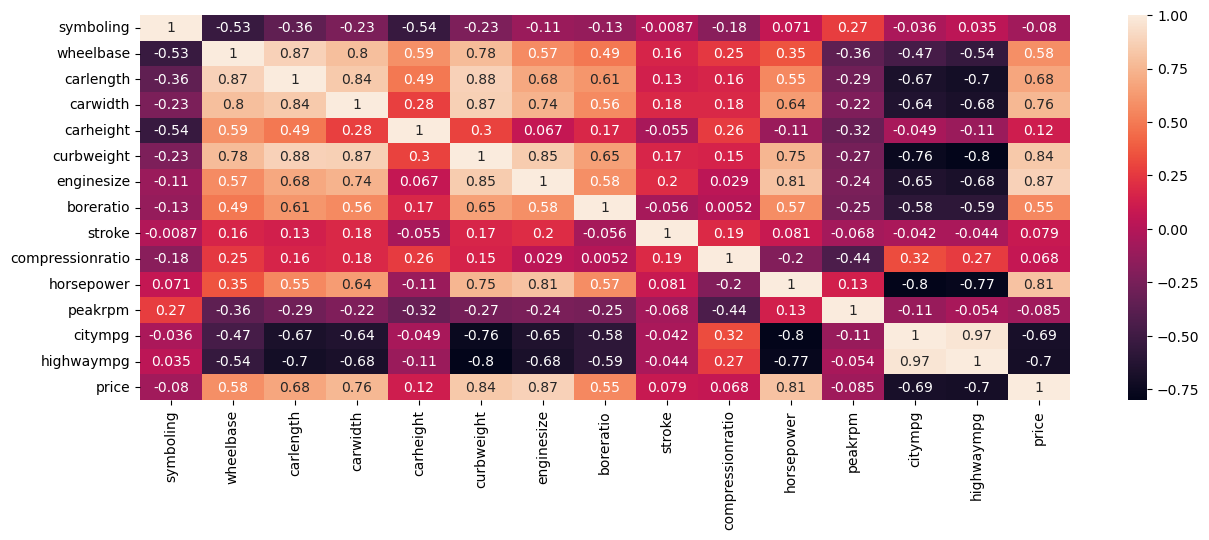

In [8]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(15,5))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

---
## Drop Low-Correlation Features

Based on the heatmap, columns with **low / redundant correlation** with price are removed.

In [9]:
cols = ["symboling","carheight","stroke","compressionratio","peakrpm","carlength","boreratio","citympg"]

In [10]:
df.drop(columns=cols,inplace = True)

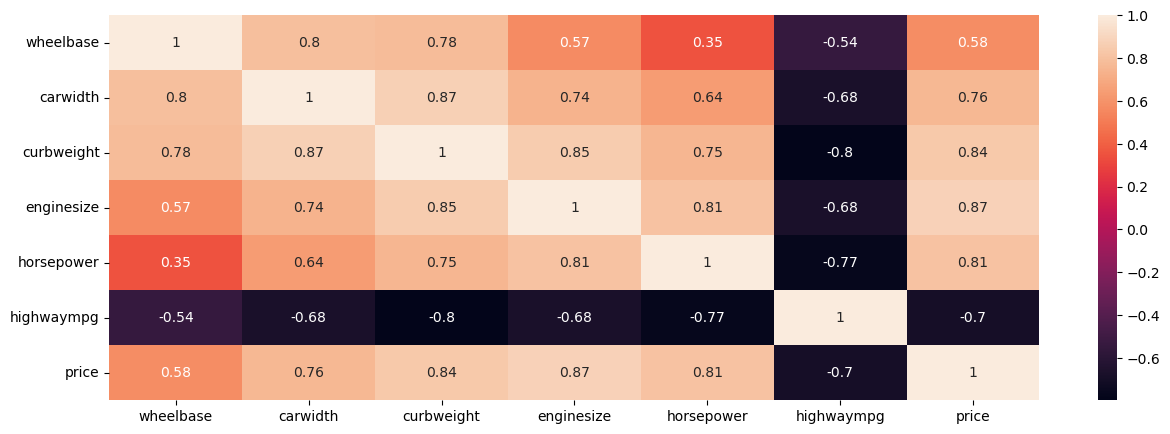

In [11]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(15,5))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [12]:
df.describe(include = object)

,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,enginetype,cylindernumber,fuelsystem
count,205,205,205,205,205,205,205,205,205,205
unique,147,2,2,2,5,3,2,7,7,8
top,peugeot 504,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,6,185,168,115,96,120,202,148,159,94


In [13]:
object_df = df.select_dtypes(include=object)
object_df

,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,enginetype,cylindernumber,fuelsystem
ID,,,,,,,,,,
1,alfa-romero giulia,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero stelvio,gas,std,two,convertible,rwd,front,dohc,four,mpfi
3,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
4,audi 100 ls,gas,std,four,sedan,fwd,front,ohc,four,mpfi
5,audi 100ls,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
201,volvo 145e (sw),gas,std,four,sedan,rwd,front,ohc,four,mpfi
202,volvo 144ea,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
203,volvo 244dl,gas,std,four,sedan,rwd,front,ohcv,six,mpfi


---
## 5 · Feature Engineering

The `name` column contains full model names like *"toyota corolla"*.  
We extract the **first word** as the brand, then fix known typos.

In [14]:
df["Brand"] = df["name"].str.split().str[0]
df.head()

,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,carwidth,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,horsepower,highwaympg,price,Brand
ID,,,,,,,,,,,,,,,,,,
1,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,64.1,2548,dohc,four,130,mpfi,111,27,13495.0,alfa-romero
2,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,64.1,2548,dohc,four,130,mpfi,111,27,16500.0,alfa-romero
3,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,65.5,2823,ohcv,six,152,mpfi,154,26,16500.0,alfa-romero
4,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,66.2,2337,ohc,four,109,mpfi,102,30,13950.0,audi
5,audi 100ls,gas,std,four,sedan,4wd,front,99.4,66.4,2824,ohc,five,136,mpfi,115,22,17450.0,audi


In [15]:
df["Brand"].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [16]:
df['Brand'] = df['Brand'].replace({'maxda': 'mazda','Nissan': 'nissan','porcshce': 'porsche','toyouta': 'toyota',
    'vokswagen': 'volkswagen','vw': 'volkswagen'})

In [17]:
df["Brand"].unique(),df["Brand"].nunique()

(array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
        'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
        'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
        'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object),
 22)

In [18]:
luxury  = ['porsche', 'jaguar', 'bmw', 'alfa-romeo', 'audi']
mid     = ['volvo', 'saab', 'volkswagen', 'buick']
economy = ['toyota', 'honda', 'nissan', 'mazda', 'dodge']

def brand_tier(i):
    if i in luxury:  return 2
    if i in mid:     return 1
    return 0

df['Brand_tier'] = df['Brand'].map(brand_tier)
df.drop(columns='Brand', inplace=True)

In [19]:
df.drop(columns="name",inplace =True)

In [20]:
object_df = df.select_dtypes(include=object)
cols = object_df.columns
for i in cols:
    print(i,"=",df[i].unique())

fueltypes = ['gas' 'diesel']
aspiration = ['std' 'turbo']
doornumbers = ['two' 'four']
carbody = ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
drivewheels = ['rwd' 'fwd' '4wd']
enginelocation = ['front' 'rear']
enginetype = ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
cylindernumber = ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
fuelsystem = ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


In [21]:
# Ordinal Encoding on cylindernumber column
cylinder_map = {'two': 2,'three': 3,'four': 4,'five': 5,'six': 6,'eight': 8,'twelve': 12}

df['cylindernumber'] = df['cylindernumber'].map(cylinder_map)

In [22]:
# Ordinal Encoding on doornumbers 
df["doornumbers"] = df['doornumbers'].map({"two" : 1,"four": 0})

In [23]:
df.head()

,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,carwidth,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,horsepower,highwaympg,price,Brand_tier
ID,,,,,,,,,,,,,,,,,
1,gas,std,1,convertible,rwd,front,88.6,64.1,2548,dohc,4,130,mpfi,111,27,13495.0,0
2,gas,std,1,convertible,rwd,front,88.6,64.1,2548,dohc,4,130,mpfi,111,27,16500.0,0
3,gas,std,1,hatchback,rwd,front,94.5,65.5,2823,ohcv,6,152,mpfi,154,26,16500.0,0
4,gas,std,0,sedan,fwd,front,99.8,66.2,2337,ohc,4,109,mpfi,102,30,13950.0,2
5,gas,std,0,sedan,4wd,front,99.4,66.4,2824,ohc,5,136,mpfi,115,22,17450.0,2


In [24]:
le = LabelEncoder()

binary_cols = ['fueltypes', 'aspiration', 'enginelocation','enginetype']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [25]:
df['fuelsystem'] = df['fuelsystem'].apply(lambda x: x if df['fuelsystem'].value_counts()[x] >= 10 else 'other')
df = pd.get_dummies(df, columns=['fuelsystem'], drop_first=True, dtype=int)
print(df.shape)

(205, 20)


In [26]:
# One Hot Encoding
ohe_cols = ['carbody', 'drivewheels']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

In [27]:
df.columns

Index(['fueltypes', 'aspiration', 'doornumbers', 'enginelocation', 'wheelbase',
       'carwidth', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize',
       'horsepower', 'highwaympg', 'price', 'Brand_tier', 'fuelsystem_2bbl',
       'fuelsystem_idi', 'fuelsystem_mpfi', 'fuelsystem_other',
       'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan',
       'carbody_wagon', 'drivewheels_fwd', 'drivewheels_rwd'],
      dtype='object')

In [28]:
df.head()

,fueltypes,aspiration,doornumbers,enginelocation,wheelbase,carwidth,curbweight,enginetype,cylindernumber,enginesize,...,fuelsystem_2bbl,fuelsystem_idi,fuelsystem_mpfi,fuelsystem_other,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheels_fwd,drivewheels_rwd
ID,,,,,,,,,,,,,,,,,,,,,
1,1,0,1,0,88.6,64.1,2548,0,4,130,...,0,0,1,0,0,0,0,0,0,1
2,1,0,1,0,88.6,64.1,2548,0,4,130,...,0,0,1,0,0,0,0,0,0,1
3,1,0,1,0,94.5,65.5,2823,5,6,152,...,0,0,1,0,0,1,0,0,0,1
4,1,0,0,0,99.8,66.2,2337,3,4,109,...,0,0,1,0,0,0,1,0,1,0
5,1,0,0,0,99.4,66.4,2824,3,5,136,...,0,0,1,0,0,0,1,0,0,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 1 to 205
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fueltypes          205 non-null    int64  
 1   aspiration         205 non-null    int64  
 2   doornumbers        205 non-null    int64  
 3   enginelocation     205 non-null    int64  
 4   wheelbase          205 non-null    float64
 5   carwidth           205 non-null    float64
 6   curbweight         205 non-null    int64  
 7   enginetype         205 non-null    int64  
 8   cylindernumber     205 non-null    int64  
 9   enginesize         205 non-null    int64  
 10  horsepower         205 non-null    int64  
 11  highwaympg         205 non-null    int64  
 12  price              205 non-null    float64
 13  Brand_tier         205 non-null    int64  
 14  fuelsystem_2bbl    205 non-null    int64  
 15  fuelsystem_idi     205 non-null    int64  
 16  fuelsystem_mpfi    205 non-null

---
## Define x and y 

In [30]:
y = df["price"]
df.drop(columns="price",inplace= True)
x = df

---
## Train / Test Split

- **Train** : 80 % of data  
- **Test**  : 20 % of data  
- **`random_state`** : 42 (reproducibility)

In [31]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=42)
xtrain,xtest,ytrain,ytest

(     fueltypes  aspiration  doornumbers  enginelocation  wheelbase  carwidth  \
 ID                                                                             
 67           0           0            0               0      104.9      66.1   
 112          1           0            0               0      107.9      68.4   
 154          1           0            0               0       95.7      63.6   
 97           1           0            0               0       94.5      63.8   
 39           1           0            1               0       96.5      65.2   
 ..         ...         ...          ...             ...        ...       ...   
 107          1           0            1               0       99.2      67.9   
 15           1           0            0               0      103.5      66.9   
 93           1           0            0               0       94.5      63.8   
 180          1           0            1               0      102.9      67.7   
 103          1           0 

---
## Create Multiple Linear Regression Model

In [32]:
mlr = LinearRegression()

In [33]:
mlr.fit(xtrain,ytrain)

LinearRegression()

In [34]:
mlr.coef_

array([ 5.76528126e+02,  2.86205043e+02, -5.23304692e+01,  8.06145969e+03,
        1.17033754e+02,  5.03485646e+02,  2.84611686e+00,  4.11870864e+02,
        2.79457788e+02,  3.63220418e+01,  2.88390744e+01, -5.18784760e+01,
        3.09502761e+03, -5.85651436e+02, -5.76528126e+02, -2.49503326e+03,
       -1.72722553e+03, -3.28929447e+03, -5.02182792e+03, -5.02305004e+03,
       -6.55480357e+03,  1.91513619e+01,  1.71514720e+03])

In [35]:
mlr.intercept_

np.float64(-43405.12540975509)

---
##  Model Evaluation & Metrics

### Predictions


In [36]:
ypred = mlr.predict(xtest)
ypred

array([27158.71367107, 21463.21442614, 10082.1694122 , 13829.32078457,
       25031.69424997,  6431.81752645,  6640.75975192,  7465.01940494,
        7198.90488073,  9847.81299581, 15274.30794695,  8950.22360049,
       14023.34028991,  9788.08731414, 35771.19122   ,  6051.529646  ,
       -1015.78957293, 14299.32423107, 10287.53556532,  8374.88324794,
       11032.82844745, 17265.79026655,  8177.64889829,  3865.94994168,
        5943.3284767 , 28036.78637674, 14257.86403586, 16917.62398538,
        4976.78740089, 18102.15125984, 25894.61031951,  5881.9360212 ,
        5593.35562967, 23185.58707311,  7085.05435125, 27132.90169752,
        9748.26973723, 10383.47306711,  5506.85477062, 14564.01309883,
        8240.73005555])

In [37]:
mae = mean_absolute_error(ytest,ypred)
mae

2405.0229879406343

In [38]:
mse = mean_squared_error(ytest,ypred)
mse

11123800.4499063

In [39]:
rmse = np.sqrt(mse)
rmse

np.float64(3335.236191022504)

In [40]:
mape   = np.mean(np.abs((ytest - ypred) / ytest)) * 100
mape

np.float64(20.323343230329037)

In [41]:
r2 = r2_score(ytest,ypred)
r2

0.8590925528500324

In [42]:
accuracy = round(r2*100,2)
accuracy

85.91

In [43]:
print("╔══════════════════════════════════════════════╗")
print("║       FINAL MODEL PERFORMANCE SUMMARY        ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  R²  Accuracy          :  {accuracy:>6.2f} %           ║")
print(f"║  MAE                   :  ${mae:>8,.0f}          ║")
print(f"║  RMSE                  :  ${rmse:>8,.0f}          ║")
print(f"║  MAPE                  :  {mape:>7.2f} %          ║")
print(f"║  Train / Test Split    :   80 % / 20 %       ║")
print(f"║  Random State          :   42                ║")
print(f"║  Features used         :   {df.shape[1]:<3}               ║")
print("╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║       FINAL MODEL PERFORMANCE SUMMARY        ║
╠══════════════════════════════════════════════╣
║  R²  Accuracy          :   85.91 %           ║
║  MAE                   :  $   2,405          ║
║  RMSE                  :  $   3,335          ║
║  MAPE                  :    20.32 %          ║
║  Train / Test Split    :   80 % / 20 %       ║
║  Random State          :   42                ║
║  Features used         :   23                ║
╚══════════════════════════════════════════════╝


---
## 📝 Conclusion

The **Multiple Linear Regression** model was successfully built to predict scrap/used automobile prices using **23 engineered features** across 205 vehicles.
The model achieved an **R² score of 85.91%**, indicating a strong linear relationship between the selected features and price.
Brand tier engineering, ordinal encoding, and one-hot encoding were applied to transform raw categorical data into model-ready features.


---

### 💡 Observations

* **R² ≈ 0.86** → The model explains ~86% of price variance — strong performance for a plain OLS regression with no regularisation.
* **MAE of \$2,405** means the model's average prediction is off by around \$2,405 on an individual car — reasonable given the price range of \$5,118–\$45,400.
* **MAPE of 20.32%** reflects larger percentage errors on cheaper vehicles, where even a small dollar gap is a high relative miss.
* **Brand Tier** is a meaningful engineered feature — luxury brands (Porsche, Jaguar, BMW) command a large price premium well captured by the tier mapping.
* **Residuals are slightly heteroscedastic** (larger errors at high prices). A log-transform on `price` could reduce this and improve RMSE.
* Dropping low-correlation features (`citympg`, `compressionratio`, `stroke`, etc.) simplified the model without sacrificing accuracy.

---